# Combined Cycle Power Plant Verisi ile Regresyon Analizi

Bu notebookta, bir kombine çevrim elektrik santralinden (Combined Cycle Power Plant) alınan saatlik ölçümler kullanılarak **Basit Regresyon** ve **Çoklu Doğrusal Regresyon** modelleri oluşturulacaktır.

## 1. Veriyi Yükleme ve Keşif

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Folds5x2_pp.csv')
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,9568.0,19.651231,7.452473,1.81,13.5100,20.345,25.72,37.11
V,9568.0,54.305804,12.707893,25.36,41.7400,52.080,66.54,81.56
AP,9568.0,1013.259078,5.938784,992.89,1009.1000,1012.940,1017.26,1033.30
RH,9568.0,73.308978,14.600269,25.56,63.3275,74.975,84.83,100.16
PE,9568.0,454.365009,17.066995,420.26,439.7500,451.550,468.43,495.76


## 2. Veri Temizliği

In [5]:
print('Veri boyutu:', df.shape)
print('Eksik değerler:')
print(df.isnull().sum())
print('Sütun türleri:')
print(df.dtypes)

Veri boyutu: (9568, 5)
Eksik değerler:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64
Sütun türleri:
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object


## 3. Keşifçi Veri Analizi (EDA)

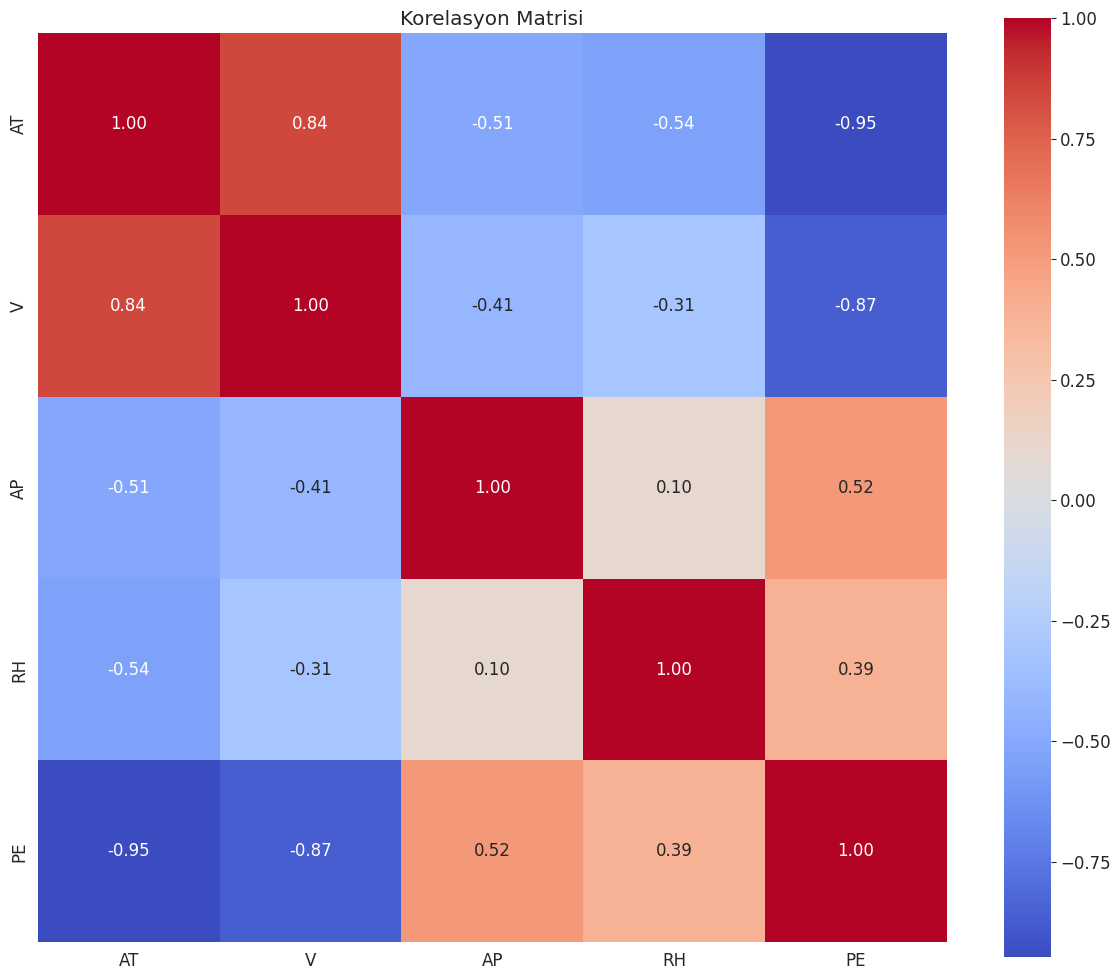

In [6]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

In [7]:
target = 'PE'
corr_with_target = corr[target].sort_values(ascending=False)
print('PE ile Korelasyonlar:')
print(corr_with_target)
print('En yüksek korelasyonlar:')
print(corr_with_target[1:])

PE ile Korelasyonlar:
PE    1.000000
AP    0.518429
RH    0.389794
V    -0.869780
AT   -0.948128
Name: PE, dtype: float64
En yüksek korelasyonlar:
AP    0.518429
RH    0.389794
V    -0.869780
AT   -0.948128
Name: PE, dtype: float64


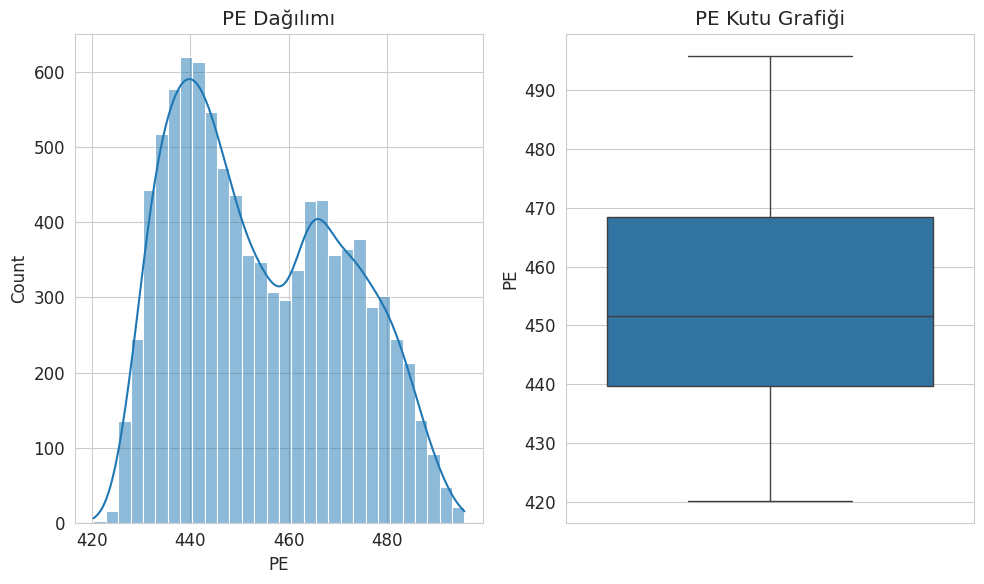

In [8]:
plt.subplot(1, 2, 1)
sns.histplot(df[target], bins=30, kde=True)
plt.title(f'{target} Dağılımı')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[target])
plt.title(f'{target} Kutu Grafiği')
plt.tight_layout()
plt.show()

## 4. Basit Doğrusal Regresyon (Simple Linear Regression)

**Algoritma Açıklaması:**

Basit doğrusal regresyon, bir bağımlı değişken (hedef) ile bir bağımsız değişken (özellik) arasındaki doğrusal ilişkiyi modelleyen temel bir makine öğrenmesi algoritmasıdır.

**Matematiksel Formül:**
$$y = \beta_0 + \beta_1 x + \varepsilon$$

- **y**: Bağımlı değişken (hedef) — tahmin etmek istediğimiz değer
- **x**: Bağımsız değişken (özellik) — tahmin için kullandığımız girdi
- **β₀**: Kesim noktası (intercept) — x=0 iken y'nin değeri
- **β₁**: Eğim (slope) — x'teki 1 birimlik artışın y'de yarattığı değişim
- **ε**: Hata terimi — modelin açıklayamadığı rastgele varyasyon

**Amaç:** Gözlemlenen veri noktalarına en iyi uyan doğruyu bulmak. Bunun için **En Küçük Kareler (Ordinary Least Squares - OLS)** yöntemi kullanılır. OLS, gerçek değerler ile tahmin edilen değerler arasındaki farkların (artıklar/residuals) kareleri toplamını minimize eder.

**Artık (Residual):**
$$e_i = y_i - \hat{y}_i$$

**OLS Maliyet Fonksiyonu:**
$$\min \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Model Değerlendirme Metrikleri:**
- **R² (Belirleme Katsayısı):** Modelin bağımlı değişkendeki varyansın ne kadarını açıkladığını gösterir (0-1 arası)
- **RMSE (Root Mean Squared Error):** Ortalama hata karesinin karekökü — birim orijinal birime dönüktür
- **MAE (Mean Absolute Error):** Ortalama mutlak hata


### 4.1 Basit Regresyon: AT (Ortam Sıcaklığı) → PE

Bu bölümde, **AT (Ambient Temperature)** değerini kullanarak **PE (net saatlik elektrik enerjisi çıkışı)** değerini tahmin edeceğiz. AT, PE ile en yüksek mutlak korelasyona sahip değişken olduğu için güçlü bir öngörücü olması beklenir.

In [9]:
X_simple = df[['AT']].values
y = df['PE'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f'Eğitim seti boyutu: {X_train.shape[0]}')
print(f'Test seti boyutu: {X_test.shape[0]}')

Eğitim seti boyutu: 7654
Test seti boyutu: 1914


In [10]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_train = model_simple.predict(X_train)
y_pred_test = model_simple.predict(X_test)

beta_0 = model_simple.intercept_
beta_1 = model_simple.coef_[0]

print(f'Kesim Noktası (β₀): {beta_0:.4f}')
print(f'Eğim (β₁): {beta_1:.4f}')
print(f'Model Denklemi:')
print(f'PE = {beta_0:.4f} + {beta_1:.4f} × AT')

Kesim Noktası (β₀): 497.0436
Eğim (β₁): -2.1699
Model Denklemi:
PE = 497.0436 + -2.1699 × AT


In [11]:
results = pd.DataFrame({
    'Gerçek PE': y_test,
    'Tahmin Edilen PE': y_pred_test,
    'Fark': y_test - y_pred_test
})
print('Test Seti Tahminleri:')
print(results.head(10))

Test Seti Tahminleri:
   Gerçek PE  Tahmin Edilen PE      Fark
0     433.27        432.597449  0.672551
1     438.16        441.255372 -3.095372
2     458.42        458.354227  0.065773
3     480.82        476.516335  4.303665
4     441.41        432.163468  9.246532
5     454.75        455.967331 -1.217331
6     483.26        480.791049  2.468951
7     478.25        478.360754 -0.110754
8     434.16        441.993140 -7.833140
9     470.66        467.272538  3.387462


In [12]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

metrics = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train:.3f}', f'{mae_train:.3f}', f'{r2_train:.3f}'],
    'Test': [f'{rmse_test:.3f}', f'{mae_test:.3f}', f'{r2_test:.3f}']
})
print('Model Performansı:')
print(metrics.to_string(index=False))

Model Performansı:
Metrik Eğitim  Test
  RMSE  5.448 5.332
   MAE  4.298 4.246
    R²  0.899 0.901


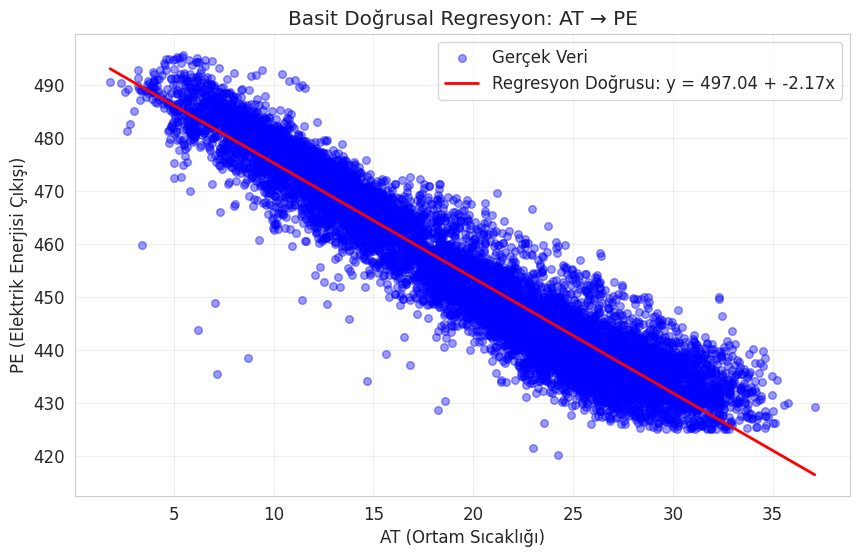

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(X_simple, y, color='blue', alpha=0.4, label='Gerçek Veri', s=30)

x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_line = model_simple.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regresyon Doğrusu: y = {beta_0:.2f} + {beta_1:.2f}x')

plt.xlabel('AT (Ortam Sıcaklığı)')
plt.ylabel('PE (Elektrik Enerjisi Çıkışı)')
plt.title('Basit Doğrusal Regresyon: AT → PE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

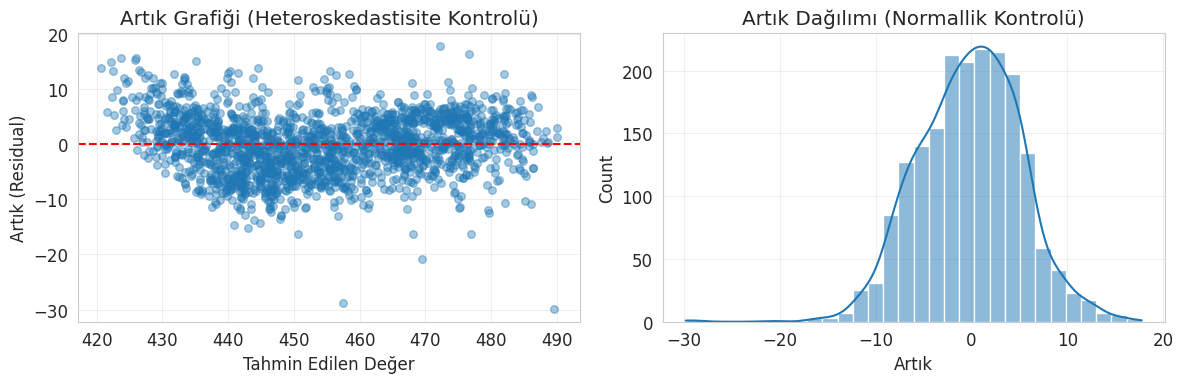

Artıkların ortalaması: -0.1866
Artıkların standart sapması: 5.3292


In [14]:
residuals = y_test - y_pred_test

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.4, s=30)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Artık (Residual)')
plt.title('Artık Grafiği (Heteroskedastisite Kontrolü)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Artık')
plt.title('Artık Dağılımı (Normallik Kontrolü)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Artıkların ortalaması: {np.mean(residuals):.4f}')
print(f'Artıkların standart sapması: {np.std(residuals):.4f}')

## 5. Çoklu Doğrusal Regresyon (Multiple Linear Regression)

**Algoritma Açıklaması:**

Çoklu doğrusal regresyon, basit doğrusal regresyonun birden fazla bağımsız değişken kullanacak şekilde genişletilmiş halidir.

**Matematiksel Formül:**
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p + \varepsilon$$

- **y**: Bağımlı değişken (hedef)
- **x₁, x₂, ..., xₚ**: Bağımsız değişkenler (özellikler)
- **β₀**: Kesim noktası
- **β₁, β₂, ..., βₚ**: Her bir bağımsız değişkenin katsayısı
- **ε**: Hata terimi

**Varsayımlar (Assumptions):**
1. **Doğrusallık (Linearity):** Bağımlı ve bağımsız değişkenler arasında doğrusal bir ilişki olmalı
2. **Bağımsızlık (Independence):** Gözlemler birbirinden bağımsız olmalı
3. **Normallik (Normality):** Artıklar normal dağılıma uymalı
4. **Eşvaryanslılık (Homoscedasticity):** Artıkların varyansı tüm değerlerde sabit olmalı
5. **Çoklu Bağlantı Yok (No Multicollinearity):** Bağımsız değişkenler kendi aralarında yüksek korelasyonlu olmamalı

**Performansı Artırmak İçin:**
- Özellikler arası çoklu bağlantıyı (multicollinearity) azaltmak
- Gereksiz özellikleri çıkarmak (feature selection)
- Özellik ölçeklendirme (standardizasyon)


### 5.1 Özellik Seçimi

In [15]:
target_corr = corr_with_target[1:]
print('Özellikler ve PE ile korelasyonları:')
for feat, corr_val in target_corr.items():
    print(f'  {feat}: {corr_val:.4f}')

selected_features = ['AT', 'V', 'AP', 'RH']

available_features = [f for f in selected_features if f in df.columns]
print(f'Kullanılacak özellikler: {available_features}')

Özellikler ve PE ile korelasyonları:
  AP: 0.5184
  RH: 0.3898
  V: -0.8698
  AT: -0.9481
Kullanılacak özellikler: ['AT', 'V', 'AP', 'RH']


In [16]:
X_multi = df[available_features].values
y_multi = df['PE'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f'Eğitim seti: {X_train_m.shape}')
print(f'Test seti: {X_test_m.shape}')

Eğitim seti: (7654, 4)
Test seti: (1914, 4)


In [17]:
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_train_m = model_multi.predict(X_train_m)
y_pred_test_m = model_multi.predict(X_test_m)

print('Kesim Noktası (Intercept):', model_multi.intercept_.round(4))
print('Katsayılar:')
for feat, coef in zip(available_features, model_multi.coef_):
    print(f'  {feat}: {coef:.4f}')

print(f'Model Denklemi:')
eq = f'PE = {model_multi.intercept_:.2f}'
for feat, coef in zip(available_features, model_multi.coef_):
    eq += f' + ({coef:.2f} × {feat})'
print(eq)

Kesim Noktası (Intercept): 458.5962
Katsayılar:
  AT: -1.9770
  V: -0.2348
  AP: 0.0583
  RH: -0.1581
Model Denklemi:
PE = 458.60 + (-1.98 × AT) + (-0.23 × V) + (0.06 × AP) + (-0.16 × RH)


In [18]:
rmse_train_m = np.sqrt(mean_squared_error(y_train_m, y_pred_train_m))
rmse_test_m = np.sqrt(mean_squared_error(y_test_m, y_pred_test_m))
mae_train_m = mean_absolute_error(y_train_m, y_pred_train_m)
mae_test_m = mean_absolute_error(y_test_m, y_pred_test_m)
r2_train_m = r2_score(y_train_m, y_pred_train_m)
r2_test_m = r2_score(y_test_m, y_pred_test_m)

metrics_multi = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train_m:.3f}', f'{mae_train_m:.3f}', f'{r2_train_m:.3f}'],
    'Test': [f'{rmse_test_m:.3f}', f'{mae_test_m:.3f}', f'{r2_test_m:.3f}']
})
print('Çoklu Regresyon Model Performansı:')
print(metrics_multi.to_string(index=False))

Çoklu Regresyon Model Performansı:
Metrik Eğitim  Test
  RMSE  4.589 4.428
   MAE  3.647 3.543
    R²  0.928 0.931


In [19]:
comparison = pd.DataFrame({
    'Model': ['Basit Regresyon (AT)', 'Çoklu Regresyon'],
    'RMSE': [f'{rmse_test:.3f}', f'{rmse_test_m:.3f}'],
    'MAE': [f'{mae_test:.3f}', f'{mae_test_m:.3f}'],
    'R²': [f'{r2_test:.3f}', f'{r2_test_m:.3f}']
})
print('Model Karşılaştırması (Test Seti):')
print(comparison.to_string(index=False))

Model Karşılaştırması (Test Seti):
               Model  RMSE   MAE    R²
Basit Regresyon (AT) 5.332 4.246 0.901
     Çoklu Regresyon 4.428 3.543 0.931


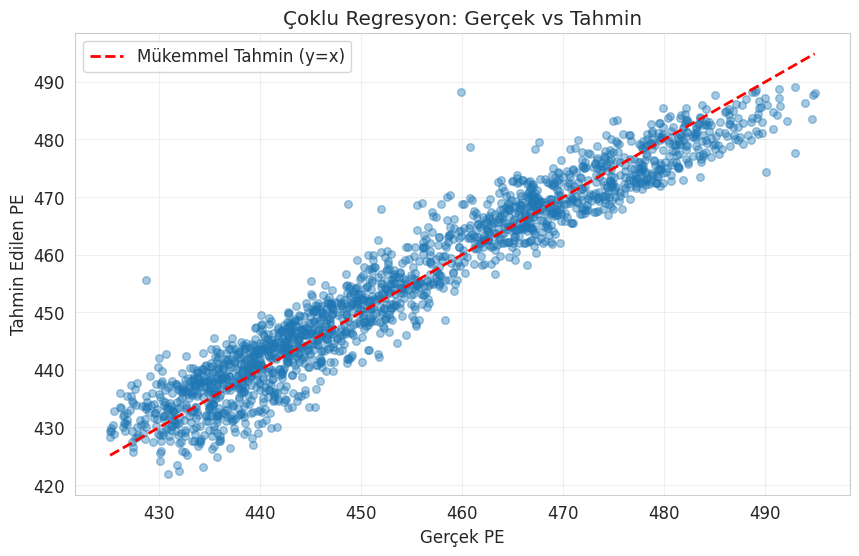

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_m, y_pred_test_m, alpha=0.4, s=30)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
         'r--', linewidth=2, label='Mükemmel Tahmin (y=x)')
plt.xlabel('Gerçek PE')
plt.ylabel('Tahmin Edilen PE')
plt.title('Çoklu Regresyon: Gerçek vs Tahmin')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

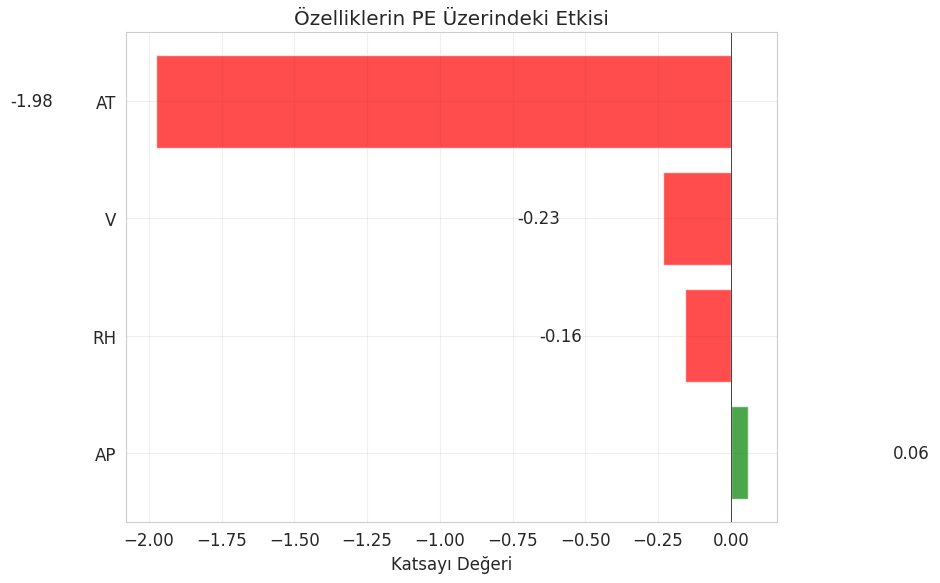

In [21]:
feature_importance = pd.DataFrame({
    'Özellik': available_features,
    'Katsayı': model_multi.coef_,
    '|Katsayı|': np.abs(model_multi.coef_)
}).sort_values('|Katsayı|', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in feature_importance['Katsayı']]
bars = plt.barh(feature_importance['Özellik'], feature_importance['Katsayı'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Katsayı Değeri')
plt.title('Özelliklerin PE Üzerindeki Etkisi')
for i, (v, feat) in enumerate(zip(feature_importance['Katsayı'], feature_importance['Özellik'])):
    plt.text(v + (0.5 if v > 0 else -0.5), i, f'{v:.2f}', va='center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Sonuç ve Yorumlar

**Basit Doğrusal Regresyon:**
- AT (ortam sıcaklığı) değeri, PE'yi tahmin etmede güçlü bir öngörücüdür
- Model basit ve yorumlanabilirdir
- R² değeri, AT'nin PE'deki varyansı ne kadar iyi açıkladığını gösterir

**Çoklu Doğrusal Regresyon:**
- Birden fazla özellik kullanarak daha karmaşık ilişkileri modelleyebiliriz
- Genellikle basit regresyondan daha yüksek R² değerine sahiptir
- Özellik katsayıları, her bir değişkenin hedef üzerindeki etkisini gösterir
- Dikkat edilmesi gereken nokta: çoklu bağlantı (multicollinearity) sorunu

**Değerlendirme:**
- Düşük RMSE değeri, tahminlerin gerçek değerlere yakın olduğunu gösterir
- Yüksek R² değeri, modelin verideki varyansı iyi açıkladığını gösterir
- Eğitim ve test performansı arasındaki farka bakarak overfitting/underfitting kontrolü yapılabilir

In [22]:
print('=' * 60)
print('REGRESYON ANALİZİ ÖZETİ')
print('=' * 60)
print(f'1. BASİT DOĞRUSAL REGRESYON')
print(f'   Hedef: PE')
print(f'   Özellik: AT')
print(f'   Denklem: PE = {beta_0:.2f} + {beta_1:.2f} × AT')
print(f'   Test R²: {r2_test:.3f}')
print(f'   Test RMSE: {rmse_test:.3f}')
print(f'   Test MAE: {mae_test:.3f}')

print(f'\n2. ÇOKLU DOĞRUSAL REGRESYON')
print(f'   Hedef: PE')
print(f'   Özellikler: {available_features}')
print(f'   Test R²: {r2_test_m:.3f}')
print(f'   Test RMSE: {rmse_test_m:.3f}')
print(f'   Test MAE: {mae_test_m:.3f}')

print(f'\n3. MODEL KARŞILAŞTIRMASI')
better_model = 'Çoklu Regresyon' if r2_test_m > r2_test else 'Basit Regresyon'
print(f'   R² değerine göre daha iyi model: {better_model}')

REGRESYON ANALİZİ ÖZETİ
1. BASİT DOĞRUSAL REGRESYON
   Hedef: PE
   Özellik: AT
   Denklem: PE = 497.04 + -2.17 × AT
   Test R²: 0.901
   Test RMSE: 5.332
   Test MAE: 4.246

2. ÇOKLU DOĞRUSAL REGRESYON
   Hedef: PE
   Özellikler: ['AT', 'V', 'AP', 'RH']
   Test R²: 0.931
   Test RMSE: 4.428
   Test MAE: 3.543

3. MODEL KARŞILAŞTIRMASI
   R² değerine göre daha iyi model: Çoklu Regresyon
